# Airbnb Data Cleaning, Transformation, and Exploratory Data Analysis

## Project Objective

Clean and analyze the NYC Airbnb dataset using Python, Pandas, NumPy, Matplotlib, and Seaborn.

The workflow includes:

- Initial dataset understanding
- Missing-value analysis
- Duplicate detection
- Data-type validation
- Categorical and numerical validation
- Outlier assessment
- Cross-column consistency checks
- Data cleaning
- Feature transformation
- Post-cleaning validation
- Exploratory data analysis
- Exporting the cleaned dataset

**Important:** Update `file_path` in the loading section to the location of your raw `AB_NYC_2019.csv` file.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Raw Dataset

In [2]:
# Update this path if your dataset is stored somewhere else.
file_path = r"C:\Users\Anjali Sonawane\OneDrive\Documents\Downloads\AB_NYC_2019.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
df.head()


Dataset loaded successfully.


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 3. Initial Dataset Understanding

In [3]:
print("Rows and columns:", df.shape)

print("\nDataset information:")
df.info()


Rows and columns: (48895, 16)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int6

In [4]:
print("First five rows:")
display(df.head())

print("\nLast five rows:")
display(df.tail())


First five rows:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0



Last five rows:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76404,-73.98933,Private room,90,7,0,NaN,NaN,1,23


In [5]:
print("Column names:")
print(df.columns.tolist())


Column names:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [6]:
print("Data types:")
display(df.dtypes)


Data types:


id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

## 4. Missing-Value Analysis

In [7]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_percentage.round(2)
}).sort_values("missing_count", ascending=False)

display(missing_summary[missing_summary["missing_count"] > 0])


,missing_count,missing_percentage
last_review,10052,20.56
reviews_per_month,10052,20.56
host_name,21,0.04
name,16,0.03


## 5. Duplicate Analysis

In [8]:
duplicate_rows = df.duplicated().sum()
duplicate_ids = df["id"].duplicated().sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate listing IDs:", duplicate_ids)


Duplicate rows: 0
Duplicate listing IDs: 0


In [9]:
if duplicate_rows > 0:
    display(df[df.duplicated(keep=False)].sort_values("id"))
else:
    print("No duplicate rows found.")


No duplicate rows found.


## 6. Categorical-Column Analysis

In [10]:
categorical_columns = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

for column in categorical_columns:
    print(f"\n{column}")
    print("Unique values:", df[column].nunique(dropna=True))
    display(df[column].value_counts(dropna=False).head(20))



neighbourhood_group
Unique values: 5


neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64


neighbourhood
Unique values: 221


neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
East Harlem           1117
Greenpoint            1115
Chelsea               1113
Lower East Side        911
Astoria                900
Washington Heights     899
West Village           768
Financial District     744
Flatbush               621
Clinton Hill           572
Name: count, dtype: int64


room_type
Unique values: 3


room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

## 7. Numerical-Column Analysis

In [11]:
numeric_columns = [
    "latitude",
    "longitude",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

display(df[numeric_columns].describe().T)


,count,mean,std,min,25%,50%,75%,max
latitude,48895.0,40.728949,0.054530,40.49979,40.69010,40.72307,40.763115,40.91306
longitude,48895.0,-73.952170,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
price,48895.0,152.720687,240.154170,0.00000,69.00000,106.00000,175.000000,10000.00000
minimum_nights,48895.0,7.029962,20.510550,1.00000,1.00000,3.00000,5.000000,1250.00000
number_of_reviews,48895.0,23.274466,44.550582,0.00000,1.00000,5.00000,24.000000,629.00000
reviews_per_month,38843.0,1.373221,1.680442,0.01000,0.19000,0.72000,2.020000,58.50000
calculated_host_listings_count,48895.0,7.143982,32.952519,1.00000,1.00000,1.00000,2.000000,327.00000
availability_365,48895.0,112.781327,131.622289,0.00000,0.00000,45.00000,227.000000,365.00000


## 8. Range and Constraint Checks

In [12]:
print("Price values less than or equal to zero:",
      (df["price"] <= 0).sum())

print("Minimum nights less than one:",
      (df["minimum_nights"] < 1).sum())

print("Availability outside 0-365:",
      (~df["availability_365"].between(0, 365)).sum())

print("Negative number of reviews:",
      (df["number_of_reviews"] < 0).sum())

print("Negative reviews per month:",
      (df["reviews_per_month"] < 0).sum())

print("Invalid latitude values:",
      (~df["latitude"].between(-90, 90)).sum())

print("Invalid longitude values:",
      (~df["longitude"].between(-180, 180)).sum())


Price values less than or equal to zero: 11
Minimum nights less than one: 0
Availability outside 0-365: 0
Negative number of reviews: 0
Negative reviews per month: 0
Invalid latitude values: 0
Invalid longitude values: 0


## 9. Outlier Assessment

In [13]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = df[
    (df["price"] < lower_bound) |
    (df["price"] > upper_bound)
]

print("Price Q1:", Q1)
print("Price Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of price outliers:", len(price_outliers))

display(
    price_outliers[
        ["id", "name", "neighbourhood_group", "room_type", "price"]
    ].head(20)
)


Price Q1: 69.0
Price Q3: 175.0
IQR: 106.0
Lower bound: -90.0
Upper bound: 334.0
Number of price outliers: 2972


,id,name,neighbourhood_group,room_type,price
61,15396,Sunny & Spacious Chelsea Apartment,Manhattan,Entire home/apt,375
85,19601,perfect for a family or small group,Brooklyn,Entire home/apt,800
103,23686,2000 SF 3br 2bath West Village private townhouse,Manhattan,Entire home/apt,500
114,26933,2 BR / 2 Bath Duplex Apt with patio! East Village,Manhattan,Entire home/apt,350
121,27659,3 Story Town House in Park Slope,Brooklyn,Entire home/apt,400
158,38663,Luxury Brownstone in Boerum Hill,Brooklyn,Entire home/apt,475
181,45910,Beautiful Queens Brownstone! - 5BR,Queens,Entire home/apt,350
233,60164,"Beautiful, elegant 3 bed SOHO loft",Manhattan,Entire home/apt,500
242,61224,Huge Chelsea Loft,Manhattan,Entire home/apt,500
263,63693,Cottage in the Village,Manhattan,Entire home/apt,390


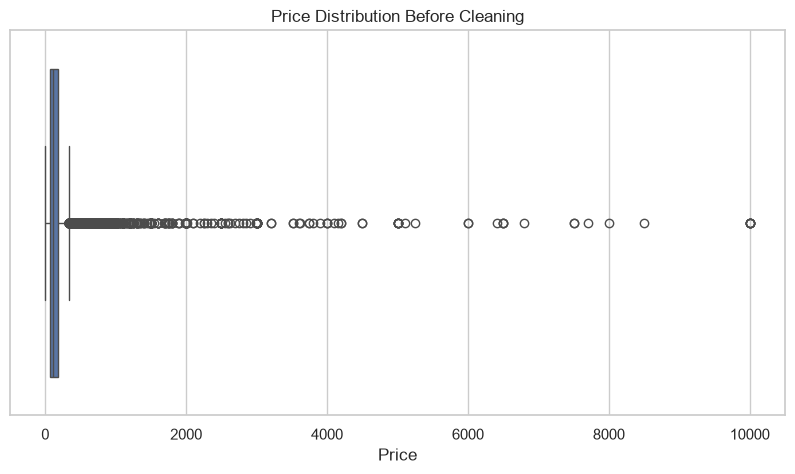

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["price"])
plt.title("Price Distribution Before Cleaning")
plt.xlabel("Price")
plt.show()


## 10. Cross-Column Consistency Checks

In [15]:
zero_review_listings = df[df["number_of_reviews"] == 0]
reviewed_listings = df[df["number_of_reviews"] > 0]

print("Listings with zero reviews:", len(zero_review_listings))
print("Listings with at least one review:", len(reviewed_listings))

print("\nMissing reviews_per_month among zero-review listings:",
      zero_review_listings["reviews_per_month"].isnull().sum())

print("Missing reviews_per_month among reviewed listings:",
      reviewed_listings["reviews_per_month"].isnull().sum())


Listings with zero reviews: 10052
Listings with at least one review: 38843

Missing reviews_per_month among zero-review listings: 10052
Missing reviews_per_month among reviewed listings: 0


In [16]:
# Check whether listings with zero reviews have a last_review date
inconsistent_zero_review_dates = zero_review_listings[
    zero_review_listings["last_review"].notna()
]

print(
    "Zero-review listings with a last_review date:",
    len(inconsistent_zero_review_dates)
)


Zero-review listings with a last_review date: 0


## 11. Begin Data Cleaning

In [17]:
df_clean = df.copy()

print("Original shape:", df.shape)
print("Working-copy shape:", df_clean.shape)


Original shape: (48895, 16)
Working-copy shape: (48895, 16)


### 11.1 Remove Exact Duplicate Rows and Duplicate IDs

In [18]:
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.drop_duplicates(subset="id", keep="first")

print("Shape after duplicate removal:", df_clean.shape)
print("Duplicate rows remaining:", df_clean.duplicated().sum())
print("Duplicate IDs remaining:", df_clean["id"].duplicated().sum())


Shape after duplicate removal: (48895, 16)
Duplicate rows remaining: 0
Duplicate IDs remaining: 0


### 11.2 Clean Text Columns

In [19]:
text_columns = [
    "name",
    "host_name",
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

for column in text_columns:
    df_clean[column] = df_clean[column].str.strip()

print("Text columns cleaned.")


Text columns cleaned.


### 11.3 Handle Missing Text Values

In [20]:
df_clean["name"] = df_clean["name"].fillna("Unknown")
df_clean["host_name"] = df_clean["host_name"].fillna("Unknown")

print("Missing names:", df_clean["name"].isnull().sum())
print("Missing host names:", df_clean["host_name"].isnull().sum())


Missing names: 0
Missing host names: 0


### 11.4 Handle Review-Related Missing Values

In [21]:
zero_review_mask = df_clean["number_of_reviews"] == 0

df_clean.loc[
    zero_review_mask,
    "reviews_per_month"
] = df_clean.loc[
    zero_review_mask,
    "reviews_per_month"
].fillna(0)

print(
    "Missing reviews_per_month after conditional filling:",
    df_clean["reviews_per_month"].isnull().sum()
)


Missing reviews_per_month after conditional filling: 0


In [22]:
# Inspect remaining missing review-rate values.
remaining_review_rate_missing = df_clean[
    df_clean["reviews_per_month"].isnull()
]

print("Remaining missing reviews_per_month:",
      len(remaining_review_rate_missing))

display(
    remaining_review_rate_missing[
        ["id", "number_of_reviews", "reviews_per_month"]
    ].head(20)
)


Remaining missing reviews_per_month: 0


,id,number_of_reviews,reviews_per_month


### 11.5 Convert Date Column

In [23]:
df_clean["last_review"] = pd.to_datetime(
    df_clean["last_review"],
    errors="coerce"
)

print(df_clean["last_review"].dtype)


datetime64[us]


### 11.6 Remove Invalid Prices

In [24]:
invalid_price_count = (df_clean["price"] <= 0).sum()

print("Invalid price rows:", invalid_price_count)

df_clean = df_clean[df_clean["price"] > 0].copy()

print("Shape after removing invalid prices:", df_clean.shape)
print(
    "Remaining invalid prices:",
    (df_clean["price"] <= 0).sum()
)


Invalid price rows: 11
Shape after removing invalid prices: (48884, 16)
Remaining invalid prices: 0


### 11.7 Handle Other Invalid Numeric Values

In [25]:
# Remove records that violate essential numeric constraints.
df_clean = df_clean[df_clean["minimum_nights"] >= 1].copy()
df_clean = df_clean[df_clean["number_of_reviews"] >= 0].copy()
df_clean = df_clean[df_clean["availability_365"].between(0, 365)].copy()
df_clean = df_clean[df_clean["reviews_per_month"].fillna(0) >= 0].copy()

print("Shape after numeric validation filtering:", df_clean.shape)


Shape after numeric validation filtering: (48884, 16)


## 12. Post-Cleaning Validation

In [26]:
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)
print("Rows removed:", len(df) - len(df_clean))


Original dataset shape: (48895, 16)
Cleaned dataset shape: (48884, 16)
Rows removed: 11


In [27]:
cleaned_missing_summary = pd.DataFrame({
    "missing_count": df_clean.isnull().sum(),
    "missing_percentage": (
        df_clean.isnull().sum() / len(df_clean) * 100
    ).round(2)
}).sort_values("missing_count", ascending=False)

display(cleaned_missing_summary[cleaned_missing_summary["missing_count"] > 0])


,missing_count,missing_percentage
last_review,10051,20.56


In [28]:
assert df_clean["id"].is_unique
assert (df_clean["price"] > 0).all()
assert (df_clean["minimum_nights"] >= 1).all()
assert df_clean["availability_365"].between(0, 365).all()
assert (df_clean["number_of_reviews"] >= 0).all()
assert (df_clean["reviews_per_month"].fillna(0) >= 0).all()

print("All cleaning validations passed.")


All cleaning validations passed.


## 13. Data Transformation

In [29]:
df_transformed = df_clean.copy()

print("Dataset shape before transformation:", df_transformed.shape)


Dataset shape before transformation: (48884, 16)


In [30]:
# Binary feature indicating whether a listing has reviews.
df_transformed["has_reviews"] = (
    df_transformed["number_of_reviews"] > 0
).astype(int)

display(
    df_transformed[
        ["number_of_reviews", "has_reviews"]
    ].head(10)
)


,number_of_reviews,has_reviews
0,9,1
1,45,1
2,0,0
3,270,1
4,9,1
5,74,1
6,49,1
7,430,1
8,118,1
9,160,1


In [31]:
# Price categories.
def categorize_price(price):
    if price < 100:
        return "Budget"
    elif price < 250:
        return "Mid-range"
    else:
        return "Expensive"

df_transformed["price_category"] = (
    df_transformed["price"].apply(categorize_price)
)

display(df_transformed["price_category"].value_counts())


price_category
Budget       21866
Mid-range    20792
Expensive     6226
Name: count, dtype: int64

In [32]:
# Availability categories.
def categorize_availability(days):
    if days == 0:
        return "Unavailable"
    elif days <= 90:
        return "Low Availability"
    elif days <= 180:
        return "Medium Availability"
    else:
        return "High Availability"

df_transformed["availability_category"] = (
    df_transformed["availability_365"].apply(categorize_availability)
)

display(df_transformed["availability_category"].value_counts())


availability_category
Unavailable            17530
High Availability      14361
Low Availability       11711
Medium Availability     5282
Name: count, dtype: int64

## 14. Post-Transformation Validation

In [33]:
assert df_transformed["has_reviews"].isin([0, 1]).all()

assert df_transformed["price_category"].isin(
    ["Budget", "Mid-range", "Expensive"]
).all()

assert df_transformed["availability_category"].isin(
    [
        "Unavailable",
        "Low Availability",
        "Medium Availability",
        "High Availability"
    ]
).all()

print("All transformation validations passed.")


All transformation validations passed.


## 15. Exploratory Data Analysis

### 15.1 Listings by Neighbourhood Group

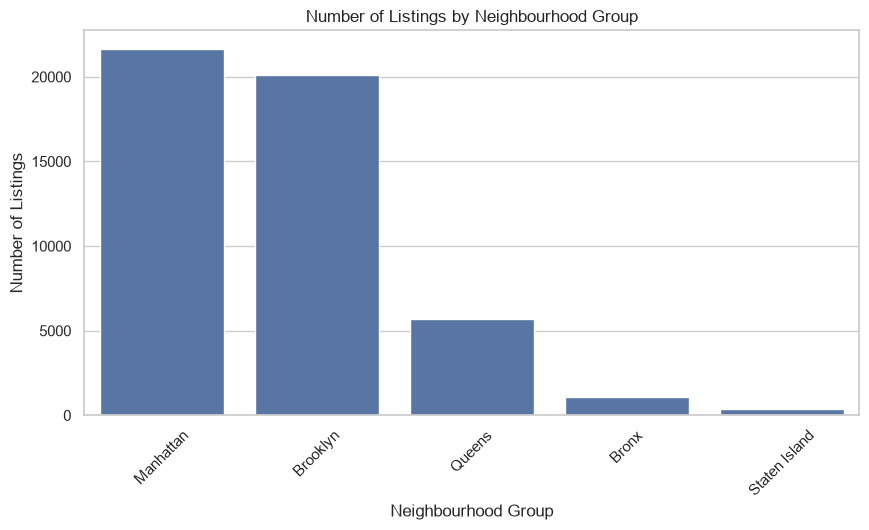

In [34]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_transformed,
    x="neighbourhood_group",
    order=df_transformed["neighbourhood_group"].value_counts().index
)
plt.title("Number of Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.show()


### 15.2 Room-Type Distribution

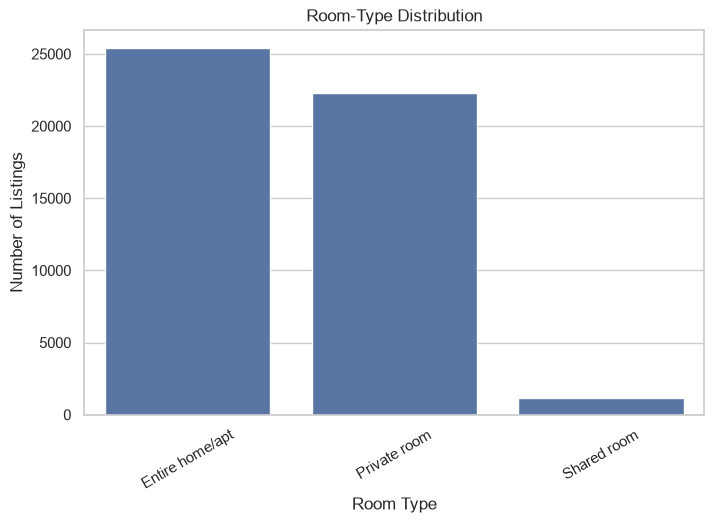

In [35]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_transformed,
    x="room_type",
    order=df_transformed["room_type"].value_counts().index
)
plt.title("Room-Type Distribution")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=30)
plt.show()


### 15.3 Average Price by Room Type

room_type
Entire home/apt    211.810918
Private room        89.809131
Shared room         70.248705
Name: price, dtype: float64

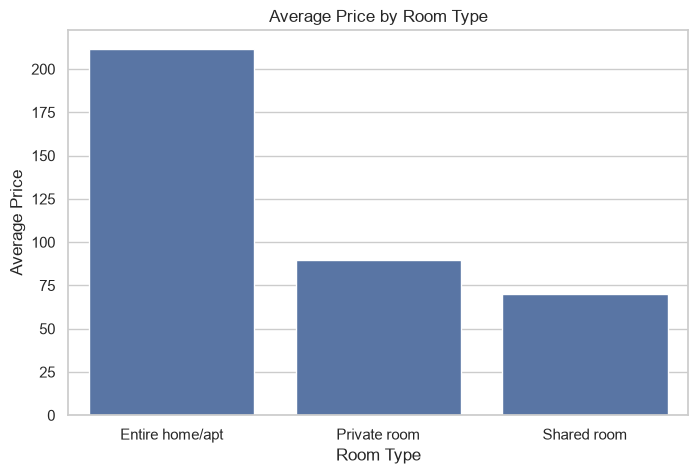

In [36]:
average_price_by_room = (
    df_transformed
    .groupby("room_type")["price"]
    .mean()
    .sort_values(ascending=False)
)

display(average_price_by_room)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=average_price_by_room.index,
    y=average_price_by_room.values
)
plt.title("Average Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price")
plt.show()


### 15.4 Average Price by Neighbourhood Group

neighbourhood_group
Manhattan        196.884903
Brooklyn         124.438915
Staten Island    114.812332
Queens            99.517649
Bronx             87.577064
Name: price, dtype: float64

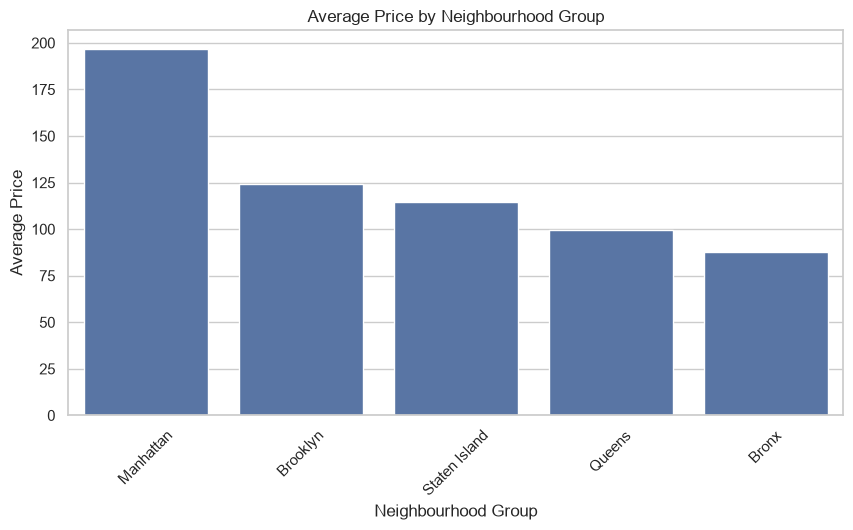

In [37]:
average_price_by_group = (
    df_transformed
    .groupby("neighbourhood_group")["price"]
    .mean()
    .sort_values(ascending=False)
)

display(average_price_by_group)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=average_price_by_group.index,
    y=average_price_by_group.values
)
plt.title("Average Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()


### 15.5 Review Distribution

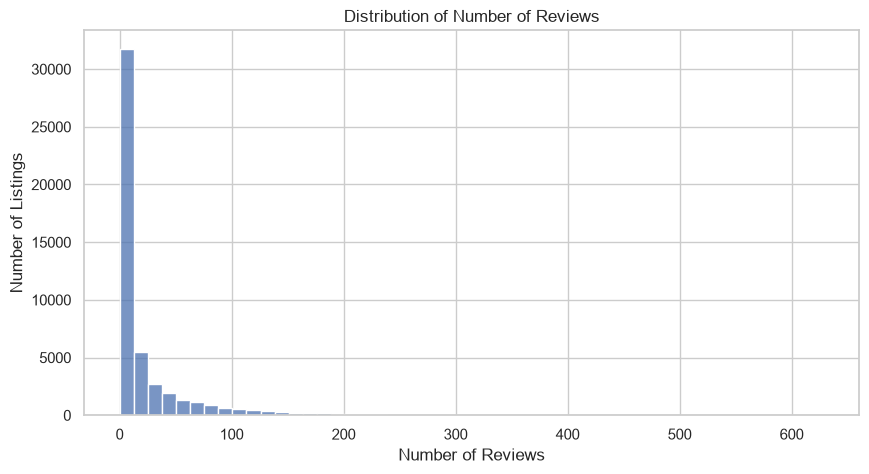

In [38]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_transformed,
    x="number_of_reviews",
    bins=50
)
plt.title("Distribution of Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Listings")
plt.show()


### 15.6 Availability Categories

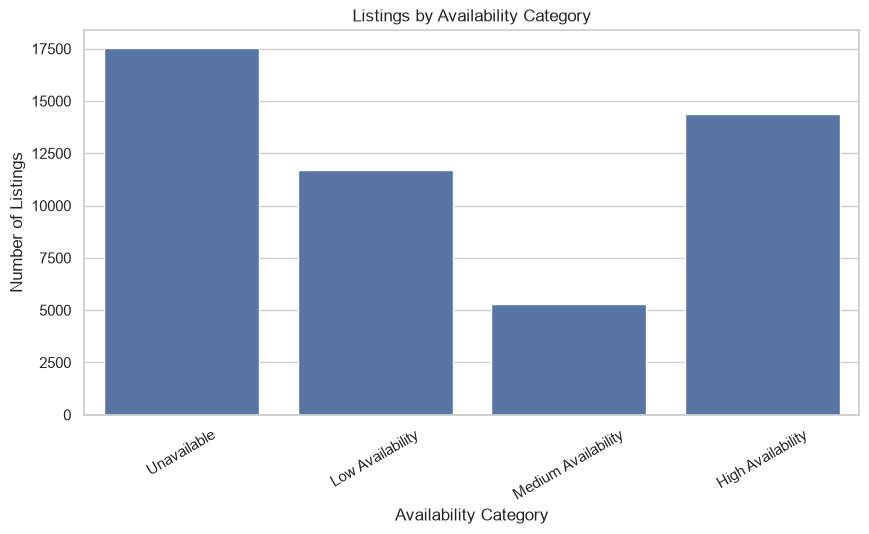

In [39]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_transformed,
    x="availability_category",
    order=[
        "Unavailable",
        "Low Availability",
        "Medium Availability",
        "High Availability"
    ]
)
plt.title("Listings by Availability Category")
plt.xlabel("Availability Category")
plt.ylabel("Number of Listings")
plt.xticks(rotation=30)
plt.show()


### 15.7 Correlation Analysis

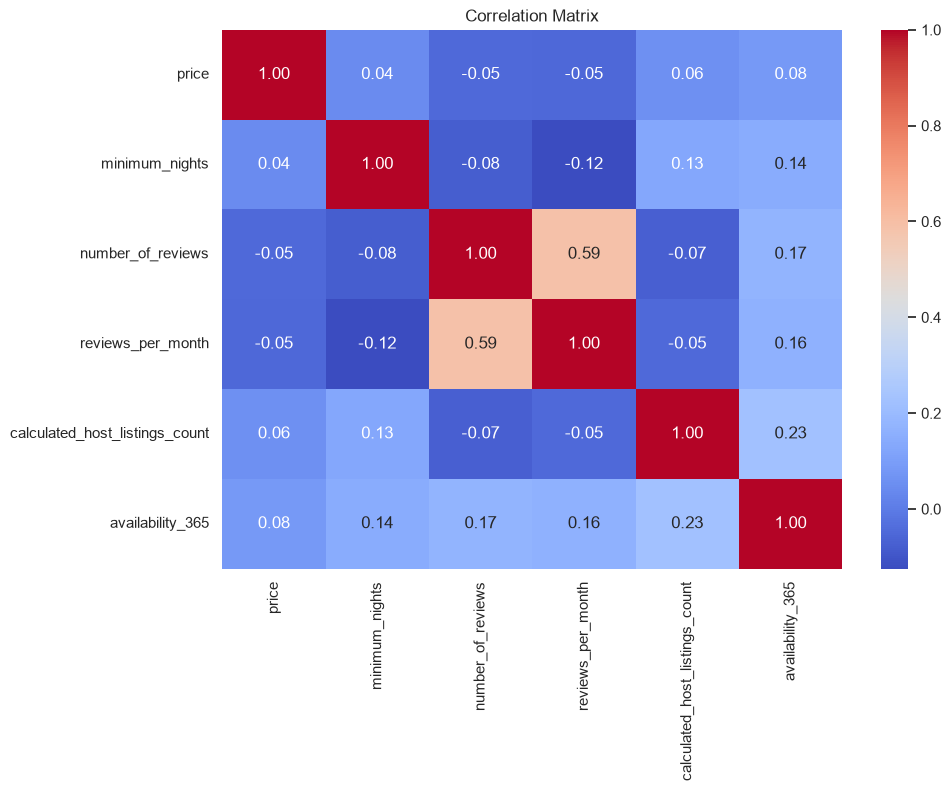

In [40]:
correlation_columns = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

correlation_matrix = df_transformed[correlation_columns].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()


## 16. Key Summary Statistics

In [41]:
summary_statistics = {
    "total_listings": len(df_transformed),
    "total_neighbourhoods": df_transformed["neighbourhood"].nunique(),
    "total_hosts": df_transformed["host_id"].nunique(),
    "average_price": round(df_transformed["price"].mean(), 2),
    "median_price": round(df_transformed["price"].median(), 2),
    "average_minimum_nights": round(
        df_transformed["minimum_nights"].mean(), 2
    ),
    "percentage_with_reviews": round(
        df_transformed["has_reviews"].mean() * 100, 2
    )
}

summary_statistics


{'total_listings': 48884,
 'total_neighbourhoods': 221,
 'total_hosts': 37455,
 'average_price': np.float64(152.76),
 'median_price': np.float64(106.0),
 'average_minimum_nights': np.float64(7.03),
 'percentage_with_reviews': np.float64(79.44)}

## 17. Export the Cleaned Dataset

In [42]:
# Export the cleaned and transformed dataset.
# The CSV will be created in the same directory as this notebook
# unless another path is specified.

output_path = "cleaned_dataset.csv"

df_transformed.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to: {output_path}")
print("Exported shape:", df_transformed.shape)


Cleaned dataset saved to: cleaned_dataset.csv
Exported shape: (48884, 19)


## 18. Verify the Exported CSV

In [43]:
exported_df = pd.read_csv(output_path)

print("Exported dataset shape:", exported_df.shape)
print("Exported columns:")
print(exported_df.columns.tolist())

display(exported_df.head())


Exported dataset shape: (48884, 19)
Exported columns:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'has_reviews', 'price_category', 'availability_category']


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,has_reviews,price_category,availability_category
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,1,Mid-range,High Availability
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,1,Mid-range,High Availability
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365,0,Mid-range,High Availability
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,1,Budget,High Availability
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,1,Budget,Unavailable


## Final Project Output

The project produces:

- `airbnb_complete_analysis.ipynb` — complete analysis notebook
- `cleaned_dataset.csv` — cleaned and transformed dataset generated by the notebook

The raw dataset is not modified.
